<a href="https://colab.research.google.com/github/themoonandsun77-cell/vigo/blob/main/projek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Sat Dec  6 08:06:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
ROOT = "/content/drive/MyDrive/skripsi_swin"
print("Root folder:", ROOT)

Root folder: /content/drive/MyDrive/skripsi_swin


In [ ]:
!pip install timm scikit-learn matplotlib seaborn

In [ ]:
import os

lc_path = ROOT + "/data/LC25000_raw"
lh_path = ROOT + "/data/LungHist700_raw"

print("Isi folder LC25000_raw:", os.listdir(lc_path))
print("Isi folder LungHist700_raw:", os.listdir(lh_path))


Isi folder LC25000_raw: ['LC25000.zip']
Isi folder LungHist700_raw: ['LungHist700.zip']


In [ ]:
import zipfile
import os

# lc_zip = ROOT + "/data/LC25000_raw/LC25000.zip"
lc_extract = ROOT + "/data/LC25000_processed/"

# with zipfile.ZipFile(lc_zip, 'r') as zip_ref:
#     zip_ref.extractall(lc_extract)

# print("LC25000 extracted to:", lc_extract)

In [ ]:
# lung_zip = ROOT + "/data/LungHist700_raw/LungHist700.zip"
lung_extract = ROOT + "/data/LungHist700/"

# with zipfile.ZipFile(lung_zip, 'r') as zip_ref:
#     zip_ref.extractall(lung_extract)

# print("LungHist700 extracted to:", lung_extract)

In [ ]:
import os

print("Isi folder LC25000_processed:")
print(os.listdir(lc_extract))

print("\nIsi folder LungHist700:")
print(os.listdir(lung_extract))


Isi folder LC25000_processed:
['LC25000']

Isi folder LungHist700:
['NORMAL', 'ACA', 'SCC']


In [ ]:
import os

lc_path = ROOT + "/data/LC25000_processed/LC25000/"
classes = ["ACA", "SCC", "NORMAL"]

print("Jumlah gambar per kelas - LC25000")
for cls in classes:
    folder = os.path.join(lc_path, cls)
    count = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    print(f"{cls}: {count} gambar")


Jumlah gambar per kelas - LC25000
ACA: 5000 gambar
SCC: 5000 gambar
NORMAL: 5000 gambar


In [ ]:
lh_path = ROOT + "/data/LungHist700/"
classes = ["ACA", "SCC", "NORMAL"]

print("Jumlah gambar per kelas - LungHist700")
for cls in classes:
    folder = os.path.join(lh_path, cls)
    count = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    print(f"{cls}: {count} gambar")


Jumlah gambar per kelas - LungHist700
ACA: 46 gambar
SCC: 49 gambar
NORMAL: 66 gambar


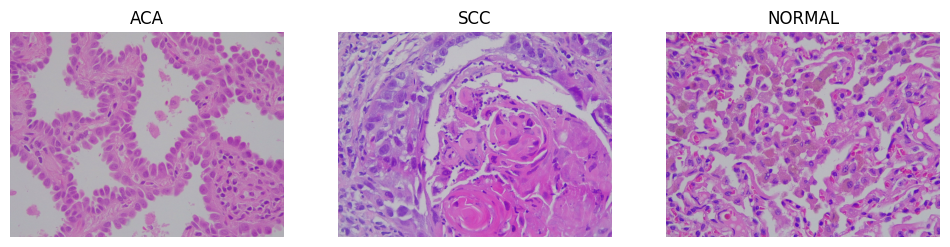

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_examples(dataset_path, classes):
    plt.figure(figsize=(12, 4))

    for i, cls in enumerate(classes):
        folder = os.path.join(dataset_path, cls)
        first_img = os.listdir(folder)[0]
        img_path = os.path.join(folder, first_img)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_examples(lh_path, ["ACA", "SCC", "NORMAL"])


In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
import torch


import torch
import torch.nn as nn
import torch.optim as optim
import timm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score



In [ ]:
import os

lc_root = os.path.join(ROOT, "data", "LC25000_processed", "LC25000")

classes = ["ACA", "SCC", "NORMAL"]

print("Path LC25000:", lc_root)
print("Jumlah gambar per kelas - LC25000")
print("-" * 50)

for cls in classes:
    folder = os.path.join(lc_root, cls)
    if not os.path.isdir(folder):
        print(f"[WARNING] Folder tidak ditemukan: {folder}")
        continue

    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"{cls:7s}: {count} gambar")


Path LC25000: /content/drive/MyDrive/skripsi_swin/data/LC25000_processed/LC25000
Jumlah gambar per kelas - LC25000
--------------------------------------------------
ACA    : 5000 gambar
SCC    : 5000 gambar
NORMAL : 5000 gambar


In [ ]:
all_image_paths = []
all_labels = []

class_to_idx = {"ACA": 0, "SCC": 1, "NORMAL": 2}

for cls in classes:
    folder = os.path.join(lc_root, cls)
    if not os.path.isdir(folder):
        print(f"[SKIP] Folder tidak ada: {folder}")
        continue

    for fname in os.listdir(folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            fpath = os.path.join(folder, fname)
            all_image_paths.append(fpath)
            all_labels.append(class_to_idx[cls])

all_image_paths = np.array(all_image_paths)
all_labels = np.array(all_labels)

print("Total gambar:", len(all_image_paths))


Total gambar: 15000


In [ ]:
# Mean & std ImageNet (RGB)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transform = T.Compose([
    # langsung crop dari gambar asli dengan skala acak
    T.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(25),
    # augmentasi warna lebih kuat (mirip stain augmentation ringan)
    T.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05,
    ),
    T.RandomApply([T.RandomAutocontrast()], p=0.3),
    T.RandomApply([T.RandomAdjustSharpness(sharpness_factor=1.5)], p=0.3),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])




In [ ]:
class HistopathDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42,
)

print("Train size :", len(X_train))
print("Test size  :", len(X_test))


Train size : 12000
Test size  : 3000


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_splits = list(skf.split(X_train, y_train))

print(f"Total fold: {len(fold_splits)}")


Total fold: 5


In [ ]:
def get_fold_loaders(fold_idx, batch_size=16, num_workers=2):
    train_idx, val_idx = fold_splits[fold_idx]

    X_tr, y_tr = X_train[train_idx], y_train[train_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    ds_train = HistopathDataset(X_tr, y_tr, transform=train_transform)
    ds_val   = HistopathDataset(X_val, y_val, transform=test_transform)

    train_loader = DataLoader(
        ds_train, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    val_loader = DataLoader(
        ds_val, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, val_loader

# coba tes untuk fold 0
train_loader_0, val_loader_0 = get_fold_loaders(0, batch_size=16)
batch_imgs, batch_labels = next(iter(train_loader_0))
print("Satu batch train - fold 0:", batch_imgs.shape, batch_labels.shape)


Satu batch train - fold 0: torch.Size([16, 3, 224, 224]) torch.Size([16])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

NUM_CLASSES = 3
CLASS_MAP = {0: "ACA", 1: "SCC", 2: "NORMAL"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def create_swin_model(num_classes=NUM_CLASSES, freeze_backbone=True):
    """
    Swin-T untuk klasifikasi 3 kelas.
    Kalau freeze_backbone=True, hanya head yang dilatih.
    """
    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.4,      # dropout sedikit lebih besar
        drop_path_rate=0.3, # stochastic depth sedikit lebih besar
    )

    if freeze_backbone:
        # Bekukan semua parameter kecuali classifier (head)
        for name, param in model.named_parameters():
            if "head" not in name:   # timm pakai "head" untuk layer akhir
                param.requires_grad = False

    return model


# def create_resnet50_model(num_classes=NUM_CLASSES):
#     model = timm.create_model(
#         "resnet50",
#         pretrained=True,
#         num_classes=num_classes
#     )
#     return model

def get_criterion():
    # klasifikasi multi-class
    return nn.CrossEntropyLoss(label_smoothing=0.1)


def get_optimizer(model, lr=1e-4, weight_decay=1e-4):
    return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import torch.nn.functional as F

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)  # [N]

        optimizer.zero_grad()

        logits = model(imgs)       # <-- HARUS [N, num_classes]
        # Cek sekali bentuknya
        # print("logits:", logits.shape, "labels:", labels.shape); break

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)  # [N]
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)    # [N, num_classes]
            loss = criterion(logits, labels)

            running_loss += loss.item() * imgs.size(0)

            probs = F.softmax(logits, dim=1)      # [N, C]
            preds = torch.argmax(probs, dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    val_loss = running_loss / len(loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)

    # precision, recall, f1 per-class (average='macro' untuk rata2)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    metrics = {
        "loss": val_loss,
        "acc": val_acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }

    # AUC opsional (butuh probabilitas & label one-vs-rest)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
        metrics["auc"] = auc
    except ValueError:
        metrics["auc"] = None  # kalau ada kelas yang tidak muncul sama sekali

    return metrics


In [ ]:
# contoh: pakai fold 0
train_loader_0, val_loader_0 = get_fold_loaders(0, batch_size=16)

model = create_swin_model(num_classes=NUM_CLASSES).to(device)
criterion = get_criterion()
optimizer = get_optimizer(model, lr=1e-4, weight_decay=1e-4)

# satu epoch saja untuk tes
train_loss, train_acc = train_one_epoch(
    model, train_loader_0, optimizer, criterion, device
)
print("Train - loss:", train_loss, "acc:", train_acc)

val_metrics = validate(model, val_loader_0, criterion, device)
print("Val metrics:", val_metrics)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import pandas as pd
import time
import torch

models_dir = os.path.join(ROOT, "models")
results_dir = os.path.join(ROOT, "results")
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print("Models dir :", models_dir)
print("Results dir:", results_dir)


Models dir : /content/drive/MyDrive/skripsi_swin/models
Results dir: /content/drive/MyDrive/skripsi_swin/results


In [ ]:
NUM_FOLDS   = 5          # 5-Fold CV
NUM_EPOCHS  = 50         # bisa kamu naikkan ke 100 nanti
BATCH_SIZE  = 16
PATIENCE    = 5          # early stopping (tidak membaik 5 epoch)
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_fold_results = []    # untuk menyimpan metric terbaik tiap fold


In [ ]:
# === TRAINING DENGAN SKIP FOLD OTOMATIS ===

from torch.optim.lr_scheduler import ReduceLROnPlateau
import os, time
import pandas as pd

all_fold_results = []

for fold in range(NUM_FOLDS):

    # --- CEK: kalau model fold ini sudah ada, SKIP ---
    best_model_path = os.path.join(models_dir, f"swin_fold{fold}.pth")
    if os.path.exists(best_model_path):
        print("="*70)
        print(f"⚠️ Fold {fold} sudah punya model terbaik.")
        print(f"   File: {best_model_path}")
        print("   → Fold ini dilewati (skip).")
        continue

    print("="*70)
    print(f"🚀 Mulai training Fold {fold}")
    print("="*70)

    # Loader
    train_loader, val_loader = get_fold_loaders(
        fold_idx=fold,
        batch_size=BATCH_SIZE,
        num_workers=2
    )

    # Model & training tools
    model = create_swin_model(num_classes=NUM_CLASSES).to(device)
    criterion = get_criterion()
    optimizer = get_optimizer(model, lr=1e-4, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_val_f1 = 0.0
    best_metrics = None
    best_epoch = 0
    no_improve = 0

    history = {
        "epoch": [],
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [], "val_f1": []
    }

    # === LOOP EPOCH ===
    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()

        # TRAIN
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # VALIDATION
        val_metrics = validate(model, val_loader, criterion, device)
        val_loss = val_metrics["loss"]
        val_acc  = val_metrics["acc"]
        val_f1   = val_metrics["f1"]

        # Scheduler pakai F1
        scheduler.step(val_f1)

        # Simpan history
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        elapsed = time.time() - start_time
        print(f"[Fold {fold}][Epoch {epoch:03d}] "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} "
              f"({elapsed:.1f}s)")

        # CEK MODEL TERBAIK
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_metrics = val_metrics.copy()
            best_epoch = epoch
            no_improve = 0

            torch.save(model.state_dict(), best_model_path)
            print(f"  ✅ Model terbaik diperbarui → {best_model_path}")
        else:
            no_improve += 1

        # EARLY STOPPING
        if no_improve >= PATIENCE:
            print(f"⛔ Early stopping di epoch {epoch} "
                  f"(tidak membaik {PATIENCE} epoch).")
            break

    # --- SELESAI 1 FOLD (hanya kalau tidak diskip) ---
    print(f"\n📌 Fold {fold} selesai. Best epoch = {best_epoch}, Best F1 = {best_val_f1:.4f}")
    print("Best metrics:", best_metrics)

    # Simpan history
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(os.path.join(results_dir, f"swin_fold{fold}_history.csv"), index=False)

    # Simpan hasil terbaik fold
    fold_result = {
        "fold": fold,
        "best_epoch": best_epoch,
        "val_loss": best_metrics["loss"],
        "val_acc": best_metrics["acc"],
        "val_precision": best_metrics["precision"],
        "val_recall": best_metrics["recall"],
        "val_f1": best_metrics["f1"],
        "val_auc": float(best_metrics["auc"]),
    }
    all_fold_results.append(fold_result)

# === REKAP HASIL FOLD YANG DILATIH DI RUN INI ===
cv_df = pd.DataFrame(all_fold_results)

if cv_df.empty:
    print("\n⚠️ Di run ini tidak ada fold yang dilatih (semua sudah di-skip).")
    print("   Kalau mau rekap lengkap 5-fold, pakai CSV gabungan atau baca "
          "hasil sebelumnya di results_dir.")
else:
    cv_df.to_csv(os.path.join(results_dir, "swin_5fold_best_metrics_run_ini.csv"), index=False)

    print("\n===== Rekap Fold yang dilatih di run ini =====")
    display(cv_df)

    print("\n===== Rata-rata dan std (ACC, F1, AUC) =====")
    print("ACC  mean±std:", cv_df["val_acc"].mean(),  "+/-", cv_df["val_acc"].std())
    print("F1   mean±std:", cv_df["val_f1"].mean(),   "+/-", cv_df["val_f1"].std())
    print("AUC  mean±std:", cv_df["val_auc"].mean(),  "+/-", cv_df["val_auc"].std())


⚠️ Fold 0 sudah punya model terbaik.
   File: /content/drive/MyDrive/skripsi_swin/models/swin_fold0.pth
   → Fold ini dilewati (skip).
⚠️ Fold 1 sudah punya model terbaik.
   File: /content/drive/MyDrive/skripsi_swin/models/swin_fold1.pth
   → Fold ini dilewati (skip).
⚠️ Fold 2 sudah punya model terbaik.
   File: /content/drive/MyDrive/skripsi_swin/models/swin_fold2.pth
   → Fold ini dilewati (skip).
⚠️ Fold 3 sudah punya model terbaik.
   File: /content/drive/MyDrive/skripsi_swin/models/swin_fold3.pth
   → Fold ini dilewati (skip).
🚀 Mulai training Fold 4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
import torch, os

# pastikan Drive sudah di-mount
save_path = "/content/drive/MyDrive/EMERGENCY_checkpoint.pth"

checkpoint = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
}

torch.save(checkpoint, save_path)
print("✅ Emergency checkpoint disimpan di:")
print(save_path)


In [ ]:
import timm
import torch
import torch.nn as nn

NUM_CLASSES = 3  # ACA, SCC, NORMAL

def create_resnet_model(num_classes=NUM_CLASSES):
    """
    ResNet50 pre-trained ImageNet, output 3 kelas (ACA, SCC, NORMAL).
    """
    model = timm.create_model(
        "resnet50",
        pretrained=True,
        num_classes=num_classes  # timm otomatis ganti classifier
    )
    return model


In [ ]:
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

max_epochs = 50        # sama seperti Swin
patience_es = 5        # early stopping
batch_size = 16

results_resnet = []

for fold in range(5):
    print("\n" + "="*70)
    print(f"🌟 Mulai training ResNet50 Fold {fold}")
    print("="*70)

    # 1. Data untuk fold ini
    train_loader, val_loader = get_fold_loaders(fold, batch_size=batch_size)

    # 2. Model, loss, optimizer, scheduler
    model = create_resnet_model(NUM_CLASSES).to(device)
    criterion = get_criterion()  # CrossEntropyLoss
    optimizer = get_optimizer(model, lr=1e-4, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_f1 = 0.0
    best_epoch = 0
    best_metrics = None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        print(f"\n[Fold {fold}] Epoch {epoch:03d}")

        # ==== TRAIN ====
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # ==== VALIDATION ====
        val_metrics = validate(model, val_loader, criterion, device)

        # scheduler berdasarkan F1 (bisa juga pakai AUC)
        scheduler.step(val_metrics["f1"])

        print(
            f"Train_loss={train_loss:.4f} acc={train_acc:.4f} | "
            f"Val_loss={val_metrics['loss']:.4f} acc={val_metrics['acc']:.4f} "
            f"f1={val_metrics['f1']:.4f}"
        )

        # ==== SIMPAN MODEL TERBAIK ====
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_epoch = epoch
            best_metrics = val_metrics.copy()

            save_path = f"{ROOT}/models/resnet_fold{fold}.pth"
            torch.save(model.state_dict(), save_path)
            print("✅ Model baru terbaik disimpan:", save_path)

            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_es:
                print(f"⛔ Early stopping di epoch {epoch} "
                      f"(tidak membaik {patience_es} epoch).")
                break

    print(
        f"\n⭐ Fold {fold} selesai. Best epoch = {best_epoch}, "
        f"best F1 = {best_f1:.4f}"
    )

    results_resnet.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "val_loss": float(best_metrics["loss"]),
        "val_acc": float(best_metrics["acc"]),
        "val_precision": float(best_metrics["precision"]),
        "val_recall": float(best_metrics["recall"]),
        "val_f1": float(best_metrics["f1"]),
        "val_auc": float(best_metrics["auc"]),
    })

# ==== REKAP HASIL 5-FOLD ====
df_resnet = pd.DataFrame(results_resnet)
print("\n===== Rekap ResNet50 5-Fold (best metrics per fold) =====")
display(df_resnet)

print("\n===== Rata-rata dan std (ACC, F1, AUC) =====")
for metric, short in [("val_acc", "ACC"), ("val_f1", "F1"), ("val_auc", "AUC")]:
    mean = df_resnet[metric].mean()
    std = df_resnet[metric].std()
    print(f"{short} mean±std: {mean:.4f} +/- {std:.4f}")



🌟 Mulai training ResNet50 Fold 0

[Fold 0] Epoch 001
Train_loss=0.5811 acc=0.8555 | Val_loss=0.3599 acc=0.9738 f1=0.9737
✅ Model baru terbaik disimpan: /content/drive/MyDrive/skripsi_swin/models/resnet_fold0.pth

[Fold 0] Epoch 002
Train_loss=0.4194 acc=0.9359 | Val_loss=0.3415 acc=0.9821 f1=0.9821
✅ Model baru terbaik disimpan: /content/drive/MyDrive/skripsi_swin/models/resnet_fold0.pth

[Fold 0] Epoch 003
Train_loss=0.3880 acc=0.9553 | Val_loss=0.3318 acc=0.9854 f1=0.9854
✅ Model baru terbaik disimpan: /content/drive/MyDrive/skripsi_swin/models/resnet_fold0.pth

[Fold 0] Epoch 004
Train_loss=0.3630 acc=0.9702 | Val_loss=0.3224 acc=0.9900 f1=0.9900
✅ Model baru terbaik disimpan: /content/drive/MyDrive/skripsi_swin/models/resnet_fold0.pth

[Fold 0] Epoch 005
Train_loss=0.3467 acc=0.9768 | Val_loss=0.3135 acc=0.9933 f1=0.9933
✅ Model baru terbaik disimpan: /content/drive/MyDrive/skripsi_swin/models/resnet_fold0.pth

[Fold 0] Epoch 006
Train_loss=0.3350 acc=0.9830 | Val_loss=0.3159 acc=

KeyboardInterrupt: 

In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np

# Dataset & loader untuk test set LC25000 (3.000 citra)
ds_test = HistopathDataset(X_test, y_test, transform=test_transform)

test_loader = DataLoader(
    ds_test,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Jumlah data test:", len(ds_test))


Jumlah data test: 3000


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def evaluate_model(model, loader, device, num_classes=3):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits = model(imgs)

            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)

    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

    y_true = labels.numpy()
    y_pred = preds.numpy()
    y_score = probs.numpy()     # untuk AUC multi-kelas

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    # One-hot untuk AUC
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr")

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
    }
    return metrics, cm


In [ ]:
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 3
CLASS_NAMES = ["ACA", "SCC", "NORMAL"]

# --- pilih fold terbaik secara manual, misalnya fold 4 ---
BEST_SWINT_FOLD  = 5
BEST_RESNET_FOLD = 2

swin_ckpt_path   = os.path.join(ROOT, "models", f"swin_fold{BEST_SWINT_FOLD}.pth")
resnet_ckpt_path = os.path.join(ROOT, "models", f"resnet_fold{BEST_RESNET_FOLD}.pth")

print("Swin checkpoint :", swin_ckpt_path)
print("ResNet checkpoint:", resnet_ckpt_path)


Swin checkpoint : /content/drive/MyDrive/skripsi_swin/models/swin_fold5.pth
ResNet checkpoint: /content/drive/MyDrive/skripsi_swin/models/resnet_fold2.pth


In [ ]:
import timm
import torch.nn as nn

def create_swin_model(num_classes=3):
    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
    )
    return model

def create_resnet_model(num_classes=3):
    model = timm.create_model(
        "resnet50",
        pretrained=True,
        num_classes=num_classes,
    )
    return model


In [ ]:
# Swin
swin_model = create_swin_model(NUM_CLASSES).to(device)
state_dict = torch.load(swin_ckpt_path, map_location=device)
swin_model.load_state_dict(state_dict)
swin_model.eval()

# ResNet
resnet_model = create_resnet_model(NUM_CLASSES).to(device)
state_dict = torch.load(resnet_ckpt_path, map_location=device)
resnet_model.load_state_dict(state_dict)
resnet_model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [ ]:
from torch.utils.data import DataLoader

# asumsi dari notebook preprocessing:
# X_test, y_test, HistopathDataset, test_transform sudah ada
ds_test = HistopathDataset(X_test, y_test, transform=test_transform)
test_loader = DataLoader(ds_test, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix

def evaluate_model(model, loader, device):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs, axis=0)  # (N, num_classes)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    # AUC macro (per kelas), butuh one-vs-rest
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "cm": cm,
    }
    return metrics


In [ ]:
swin_metrics   = evaluate_model(swin_model,   test_loader, device)
resnet_metrics = evaluate_model(resnet_model, test_loader, device)

print("=== Swin – LC25000 test ===")
print(swin_metrics)

print("\n=== ResNet – LC25000 test ===")
print(resnet_metrics)


=== Swin – LC25000 test ===
{'acc': 0.9996666666666667, 'precision': 0.9996669996669997, 'recall': 0.9996666666666667, 'f1': 0.9996666665833334, 'auc': np.float64(1.0), 'cm': array([[1000,    0,    0],
       [   1,  999,    0],
       [   0,    0, 1000]])}

=== ResNet – LC25000 test ===
{'acc': 0.9986666666666667, 'precision': 0.99867197875166, 'recall': 0.9986666666666667, 'f1': 0.9986666613333121, 'auc': np.float64(0.9999068333333333), 'cm': array([[ 996,    4,    0],
       [   0, 1000,    0],
       [   0,    0, 1000]])}


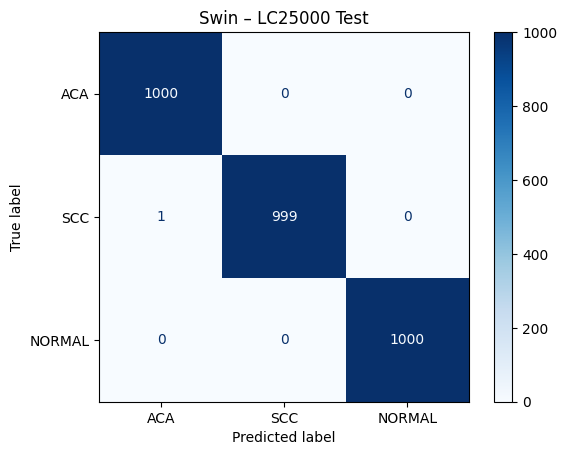

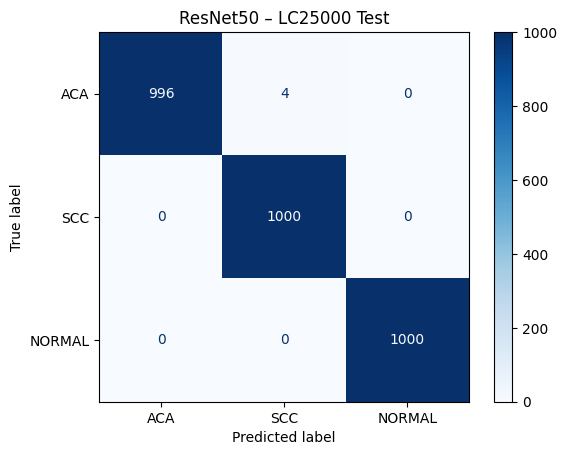

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=CLASS_NAMES)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()

plot_cm(swin_metrics["cm"],   "Swin – LC25000 Test")
plot_cm(resnet_metrics["cm"], "ResNet50 – LC25000 Test")


In [ ]:
import torchvision.transforms as T
import torch.nn as nn

class AddGaussianNoise(nn.Module):
    def __init__(self, mean=0., std=0.05):
        super().__init__()
        self.mean = mean
        self.std = std
    def forward(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

noise_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    AddGaussianNoise(0., 0.05),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

blur_transform = T.Compose([
    T.Resize((224, 224)),
    T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


NameError: name 'IMAGENET_MEAN' is not defined

In [ ]:
ds_test_noise = HistopathDataset(X_test, y_test, transform=noise_transform)
ds_test_blur  = HistopathDataset(X_test, y_test, transform=blur_transform)

loader_noise = DataLoader(ds_test_noise, batch_size=16,
                          shuffle=False, num_workers=2, pin_memory=True)
loader_blur  = DataLoader(ds_test_blur, batch_size=16,
                          shuffle=False, num_workers=2, pin_memory=True)


NameError: name 'noise_transform' is not defined

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 3
CLASSES = ["ACA", "SCC", "NORMAL"]


In [ ]:
lung_root = os.path.join(
    ROOT, "data", "LungHist700"
)
print("LungHist700 root:", lung_root)
print("Isi folder:", os.listdir(lung_root))


LungHist700 root: /content/drive/MyDrive/skripsi_swin/data/LungHist700
Isi folder: ['NORMAL', 'ACA', 'SCC']


In [ ]:
X_lung = []
y_lung = []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(lung_root, cls)
    print("Cek folder:", folder)

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
    ]
    print(f"  {cls}: {len(files)} gambar")

    for fname in files:
        X_lung.append(os.path.join(folder, fname))
        y_lung.append(label)

X_lung = np.array(X_lung)
y_lung = np.array(y_lung)

print("Total gambar LungHist700:", len(X_lung))


Cek folder: /content/drive/MyDrive/skripsi_swin/data/LungHist700/ACA
  ACA: 46 gambar
Cek folder: /content/drive/MyDrive/skripsi_swin/data/LungHist700/SCC
  SCC: 49 gambar
Cek folder: /content/drive/MyDrive/skripsi_swin/data/LungHist700/NORMAL
  NORMAL: 66 gambar
Total gambar LungHist700: 161


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


In [ ]:
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [ ]:
ds_lung = HistopathDataset(X_lung, y_lung, transform=test_transform)

lung_loader = DataLoader(
    ds_lung,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Jumlah batch LungHist700:", len(lung_loader))


Jumlah batch LungHist700: 11


In [ ]:
import timm
import torch.nn as nn

def create_swin_model(num_classes=3):
    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=num_classes,
    )
    return model

def create_resnet_model(num_classes=3):
    model = timm.create_model(
        "resnet50",
        pretrained=True,
        num_classes=num_classes,
    )
    return model


In [ ]:
import torchvision.transforms as T
import torch.nn.functional as F

tta_transforms = [
    T.Compose([]),  # original
    T.Compose([T.RandomHorizontalFlip(p=1.0)]),
    T.Compose([T.RandomVerticalFlip(p=1.0)]),
    T.Compose([T.RandomRotation(20)]),
]

def tta_predict_batch(model, images, device):
    model.eval()
    images = images.to(device)

    with torch.no_grad():
        probs_sum = 0
        for t in tta_transforms:
            aug = t(images)
            logits = model(aug)
            probs = F.softmax(logits, dim=1)
            probs_sum += probs

        probs_mean = probs_sum / len(tta_transforms)
    return probs_mean


In [ ]:
# === SWIN ===
swin_model = create_swin_model(num_classes=NUM_CLASSES).to(device)

swin_ckpt_path = os.path.join(ROOT, "models", "swin_fold5.pth")
state = torch.load(swin_ckpt_path, map_location=device)

# kalau saat save kamu pakai torch.save(model.state_dict(), path)
swin_model.load_state_dict(state)
swin_model.eval()

# === RESNET50 ===
resnet_model = create_resnet_model(num_classes=NUM_CLASSES).to(device)

resnet_ckpt_path = os.path.join(ROOT, "models", "resnet_fold2.pth")
state = torch.load(resnet_ckpt_path, map_location=device)
resnet_model.load_state_dict(state)
resnet_model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

# ======== TEST-TIME AUGMENTATION (TTA) FUNCTION ========
def tta_forward(model, imgs, device):
    """
    Melakukan prediksi dengan beberapa augmentasi saat testing
    lalu dirata-ratakan (Test-Time Augmentation).
    """

    imgs = imgs.to(device)

    # daftar augmentasi (cukup ringan, tapi efektif)
    aug_list = [
        lambda x: x,                                   # original
        lambda x: torch.flip(x, dims=[3]),            # horizontal flip
        lambda x: torch.flip(x, dims=[2]),            # vertical flip
        lambda x: torch.rot90(x, k=1, dims=[2, 3]),   # rotate 90 derajat
        lambda x: torch.rot90(x, k=3, dims=[2, 3]),   # rotate -90 derajat
    ]

    probs_sum = 0
    with torch.no_grad():
        for aug in aug_list:
            aug_imgs = aug(imgs)
            logits = model(aug_imgs)
            probs = F.softmax(logits, dim=1)
            probs_sum += probs

    # rata-rata hasil semua augmentasi
    probs_mean = probs_sum / len(aug_list)
    return probs_mean


# ======== EVALUATION DENGAN TTA ========
def evaluate_model(model, loader, device, num_classes=3):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            labels = labels.to(device)

            # === PREDIKSI DENGAN TTA (bagian terpenting) ===
            probs = tta_forward(model, imgs, device)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)

    # ====== Hitung metrik ======
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

    acc = accuracy_score(all_labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, preds, average="macro", zero_division=0
    )

    try:
        auc_val = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    except ValueError:
        auc_val = np.nan

    metrics = {
        "loss": np.nan,   # loss tidak dihitung saat testing → aman
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc_val,
    }

    return metrics, (all_labels, all_probs)


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# ======================================================
#  TTA (Test-Time Augmentation) - dipakai 3-kelas & biner
# ======================================================
def tta_forward(model, imgs, device):
    """
    Melakukan prediksi dengan beberapa augmentasi saat testing
    lalu dirata-ratakan (Test-Time Augmentation).
    """
    imgs = imgs.to(device)

    # daftar augmentasi (cukup ringan, tapi efektif)
    aug_list = [
        lambda x: x,                                   # original
        lambda x: torch.flip(x, dims=[3]),            # horizontal flip
        lambda x: torch.flip(x, dims=[2]),            # vertical flip
        lambda x: torch.rot90(x, k=1, dims=[2, 3]),   # rotate 90 derajat
        lambda x: torch.rot90(x, k=3, dims=[2, 3]),   # rotate -90 derajat
    ]

    probs_sum = 0
    with torch.no_grad():
        for aug in aug_list:
            aug_imgs = aug(imgs)
            logits = model(aug_imgs)
            probs = F.softmax(logits, dim=1)
            probs_sum += probs

    # rata-rata hasil semua augmentasi
    probs_mean = probs_sum / len(aug_list)
    return probs_mean


# ======================================================
#  EVALUASI 3-KELAS (Normal, ACA, SCC) DENGAN TTA
# ======================================================
def evaluate_model(model, loader, device, num_classes=3):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            labels = labels.to(device)

            # Prediksi pakai TTA
            probs = tta_forward(model, imgs, device)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)

    acc = accuracy_score(all_labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, preds, average="macro", zero_division=0
    )

    try:
        auc_val = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    except ValueError:
        auc_val = np.nan

    metrics = {
        "loss": np.nan,   # loss tidak dihitung saat testing
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc_val,
    }

    return metrics, (all_labels, all_probs)


# ======================================================
#  EVALUASI BINARY: NORMAL (0) vs KANKER (1)
#  (Kanker = ACA + SCC)
# ======================================================

# SESUAIKAN INI DENGAN ENCODING LABELMU
NORMAL_CLASS = 0  # ganti kalau normalmu bukan 0
ACA_CLASS    = 1  # ganti kalau ACA bukan 1
SCC_CLASS    = 2  # ganti kalau SCC bukan 2

def evaluate_model_binary(model, loader, device):
    """
    Mengubah 3 kelas (Normal, ACA, SCC) menjadi:
      0 = Normal
      1 = Kanker (ACA atau SCC)

    Output:
      metrics: dict dengan acc, precision, recall, f1, auc (binary)
      (y_true_bin, y_prob_cancer)
    """

    model.eval()
    all_probs_cancer = []
    all_labels_bin   = []

    with torch.no_grad():
        for imgs, labels in loader:
            # labels dari DataLoader biasanya masih CPU
            labels_np = labels.cpu().numpy()

            # Prediksi 3-kelas dengan TTA (tetap panggil model di device)
            probs3 = tta_forward(model, imgs, device)   # (B, 3)
            probs3_np = probs3.cpu().numpy()

            # Konversi label 3-kelas -> biner
            # 0 kalau NORMAL_CLASS, 1 kalau ACA atau SCC (kanker)
            labels_bin = (labels_np != NORMAL_CLASS).astype(int)

            # Probabilitas kanker = prob(ACA) + prob(SCC)
            p_cancer = probs3_np[:, ACA_CLASS] + probs3_np[:, SCC_CLASS]

            all_probs_cancer.append(p_cancer)
            all_labels_bin.append(labels_bin)

    y_prob_cancer = np.concatenate(all_probs_cancer)  # shape (N,)
    y_true_bin    = np.concatenate(all_labels_bin)    # shape (N,)

    # Prediksi label biner dengan threshold 0.5
    y_pred_bin = (y_prob_cancer >= 0.5).astype(int)

    # Hitung metrik
    acc = accuracy_score(y_true_bin, y_pred_bin)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, average="binary", zero_division=0
    )

    try:
        auc_val = roc_auc_score(y_true_bin, y_prob_cancer)
    except ValueError:
        auc_val = np.nan

    metrics = {
        "loss": np.nan,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc_val,
    }

    return metrics, (y_true_bin, y_prob_cancer)


In [ ]:
# Contoh: evaluasi SWIN (3-kelas)
metrics_swin_3c, _ = evaluate_model(swin_model, lung_loader, device)
print("Swin – LungHist700 (3 Kelas):")
print(metrics_swin_3c)

# Evaluasi SWIN (biner)
metrics_swin_bin, _ = evaluate_model_binary(swin_model, lung_loader, device)
print("\nSwin – LungHist700 (Biner: Normal vs Kanker):")
print(metrics_swin_bin)


Swin – LungHist700 (3 Kelas):
{'loss': nan, 'acc': 0.5714285714285714, 'precision': 0.5776515151515151, 'recall': 0.6019198193111236, 'f1': 0.5651508830482547, 'auc': np.float64(0.7716383072065013)}

Swin – LungHist700 (Biner: Normal vs Kanker):
{'loss': nan, 'acc': 0.782608695652174, 'precision': 0.8508771929824561, 'recall': 0.8434782608695652, 'f1': 0.8471615720524017, 'auc': np.float64(0.8119092627599244)}


In [ ]:
metrics_resnet_3c, _ = evaluate_model(resnet_model, lung_loader, device)
print("\nResNet50 – LungHist700 (3 Kelas):")
print(metrics_resnet_3c)

metrics_resnet_bin, _ = evaluate_model_binary(resnet_model, lung_loader, device)
print("\nResNet50 – LungHist700 (Biner: Normal vs Kanker):")
print(metrics_resnet_bin)



ResNet50 – LungHist700 (3 Kelas):
{'loss': nan, 'acc': 0.5900621118012422, 'precision': 0.6807598039215685, 'recall': 0.6376990849040539, 'f1': 0.5746654998570954, 'auc': np.float64(0.8435157168681501)}

ResNet50 – LungHist700 (Biner: Normal vs Kanker):
{'loss': nan, 'acc': 0.6521739130434783, 'precision': 0.6344827586206897, 'recall': 0.968421052631579, 'f1': 0.7666666666666667, 'auc': np.float64(0.766347687400319)}


In [ ]:
# === SWIN di LungHist700 ===
swin_metrics_lung, (y_true_lung, prob_swin_lung) = evaluate_model(
    swin_model, lung_loader, device, num_classes=NUM_CLASSES
)
print("Swin – LungHist700 metrics:", swin_metrics_lung)

# === RESNET di LungHist700 ===
resnet_metrics_lung, (y_true_lung_r, prob_resnet_lung) = evaluate_model(
    resnet_model, lung_loader, device, num_classes=NUM_CLASSES
)
print("ResNet50 – LungHist700 metrics:", resnet_metrics_lung)


Swin – LungHist700 metrics: {'loss': nan, 'acc': 0.5714285714285714, 'precision': 0.5776515151515151, 'recall': 0.6019198193111236, 'f1': 0.5651508830482547, 'auc': np.float64(0.7716383072065013)}
ResNet50 – LungHist700 metrics: {'loss': nan, 'acc': 0.4658385093167702, 'precision': 0.5666297867109226, 'recall': 0.48046122269724756, 'f1': 0.4141733120680489, 'auc': np.float64(0.7832819694828045)}


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# ======================================================
#  ENSEMBLE SWIN + RESNET – 3 KELAS
# ======================================================
def evaluate_ensemble_3c(models, loader, device):
    """
    models : list of model, contoh [swin_model, resnet_model]
    loader : DataLoader untuk LungHist700
    """

    # pastikan semua model eval
    for m in models:
        m.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            labels = labels.to(device)

            # akumulasi probabilitas dari semua model
            probs_sum = 0
            for m in models:
                probs_m = tta_forward(m, imgs, device)  # pakai TTA yang sudah dibuat
                probs_sum += probs_m

            probs = probs_sum / len(models)  # rata-rata antar-model

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)

    acc = accuracy_score(all_labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, preds, average="macro", zero_division=0
    )

    try:
        auc_val = roc_auc_score(all_labels, all_probs, multi_class="ovr")
    except ValueError:
        auc_val = np.nan

    metrics = {
        "loss": np.nan,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc_val,
    }
    return metrics, (all_labels, all_probs)


# ======================================================
#  ENSEMBLE SWIN + RESNET – BINARY (NORMAL vs KANKER)
# ======================================================
def evaluate_ensemble_binary(models, loader, device):
    """
    Binary:
      0 = Normal (NORMAL_CLASS)
      1 = Kanker (ACA_CLASS atau SCC_CLASS)
    """

    for m in models:
        m.eval()

    all_probs_cancer = []
    all_labels_bin   = []

    with torch.no_grad():
        for imgs, labels in loader:
            labels_np = labels.cpu().numpy()

            # rata-rata probabilitas 3-kelas dari semua model
            probs3_sum = 0
            for m in models:
                probs3_m = tta_forward(m, imgs, device)  # (B, 3)
                probs3_sum += probs3_m

            probs3 = probs3_sum / len(models)          # (B, 3)
            probs3_np = probs3.cpu().numpy()

            # label biner: 0 normal, 1 kanker
            labels_bin = (labels_np != NORMAL_CLASS).astype(int)

            # prob kanker = ACA + SCC
            p_cancer = probs3_np[:, ACA_CLASS] + probs3_np[:, SCC_CLASS]

            all_probs_cancer.append(p_cancer)
            all_labels_bin.append(labels_bin)

    y_prob_cancer = np.concatenate(all_probs_cancer)
    y_true_bin    = np.concatenate(all_labels_bin)

    y_pred_bin = (y_prob_cancer >= 0.5).astype(int)

    acc = accuracy_score(y_true_bin, y_pred_bin)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_bin, y_pred_bin, average="binary", zero_division=0
    )

    try:
        auc_val = roc_auc_score(y_true_bin, y_prob_cancer)
    except ValueError:
        auc_val = np.nan

    metrics = {
        "loss": np.nan,
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc_val,
    }
    return metrics, (y_true_bin, y_prob_cancer)


In [ ]:
models_ens = [swin_model, resnet_model]

# 3-KELAS
ens_3c_metrics, _ = evaluate_ensemble_3c(models_ens, lung_loader, device)
print("Ensemble Swin+ResNet – LungHist700 (3 Kelas):")
for k, v in ens_3c_metrics.items():
    print(f"{k}: {v}")

# BINARY (NORMAL vs KANKER)
ens_bin_metrics, _ = evaluate_ensemble_binary(models_ens, lung_loader, device)
print("\nEnsemble Swin+ResNet – LungHist700 (Biner: Normal vs Kanker):")
for k, v in ens_bin_metrics.items():
    print(f"{k}: {v}")


Ensemble Swin+ResNet – LungHist700 (3 Kelas):
loss: nan
acc: 0.5962732919254659
precision: 0.6173469387755102
recall: 0.6361619746712914
f1: 0.5848024316109423
auc: 0.8260351560708262

Ensemble Swin+ResNet – LungHist700 (Biner: Normal vs Kanker):
loss: nan
acc: 0.84472049689441
precision: 0.8629032258064516
recall: 0.9304347826086956
f1: 0.895397489539749
auc: 0.9056710775047259


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# ========= FUNGSI BIKIN CONFUSION MATRIX (3 KELAS) =========
def plot_confusion_matrix_3class(y_true, y_pred, class_names=None, title="Confusion Matrix - 3 Class"):
    if class_names is None:
        class_names = ["Normal", "ACA", "SCC"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


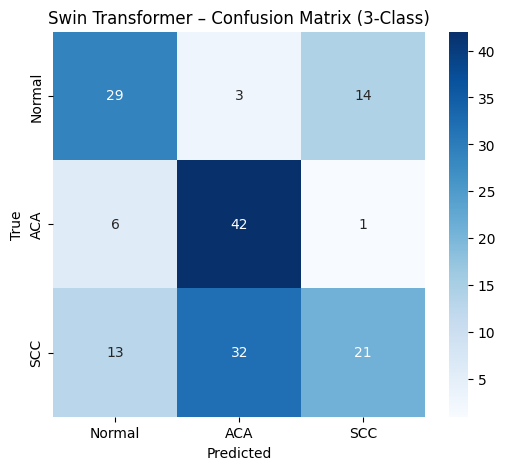

In [ ]:
metrics_swin, (labels_swin, probs_swin) = evaluate_model(swin_model, lung_loader, device)
preds_swin = probs_swin.argmax(axis=1)

plot_confusion_matrix_3class(labels_swin, preds_swin,
                             class_names=["Normal", "ACA", "SCC"],
                             title="Swin Transformer – Confusion Matrix (3-Class)")


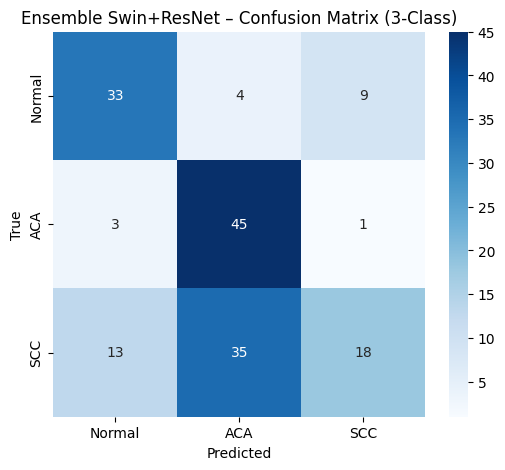

In [ ]:
ens_3c_metrics, (labels_ens3c, probs_ens3c) = evaluate_ensemble_3c(
    [swin_model, resnet_model], lung_loader, device
)
preds_ens3c = probs_ens3c.argmax(axis=1)

plot_confusion_matrix_3class(labels_ens3c, preds_ens3c,
                             class_names=["Normal", "ACA", "SCC"],
                             title="Ensemble Swin+ResNet – Confusion Matrix (3-Class)")


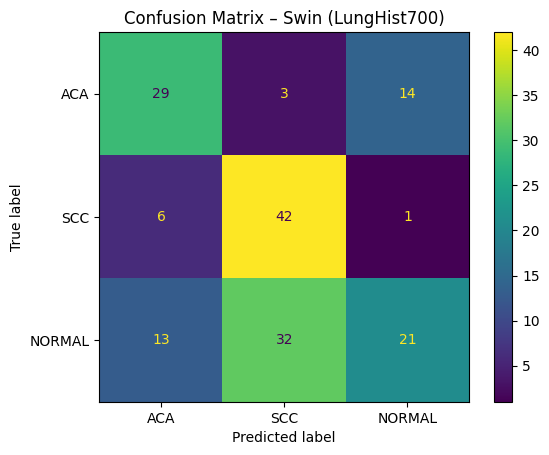

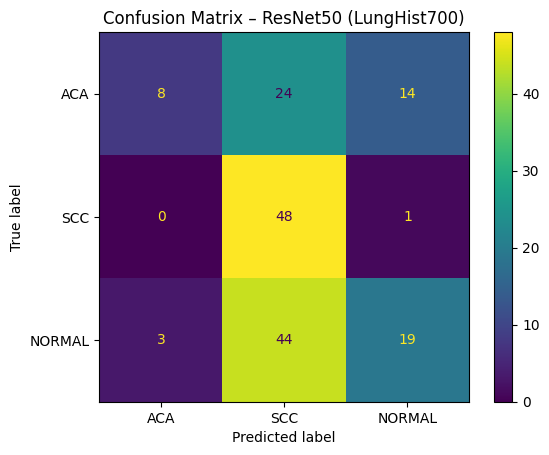

In [ ]:
import numpy as np

# Swin
pred_swin_lung = prob_swin_lung.argmax(axis=1)
cm_swin = confusion_matrix(y_true_lung, pred_swin_lung)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_swin, display_labels=CLASSES)
disp.plot()
plt.title("Confusion Matrix – Swin (LungHist700)")
plt.show()

# ResNet
pred_resnet_lung = prob_resnet_lung.argmax(axis=1)
cm_resnet = confusion_matrix(y_true_lung_r, pred_resnet_lung)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=CLASSES)
disp.plot()
plt.title("Confusion Matrix – ResNet50 (LungHist700)")
plt.show()


In [ ]:
# ========= FUNGSI BIKIN CONFUSION MATRIX (BINARY) =========
def plot_confusion_matrix_binary(y_true, y_pred, title="Confusion Matrix - Binary"):
    class_names = ["Normal", "Kanker"]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
                xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()


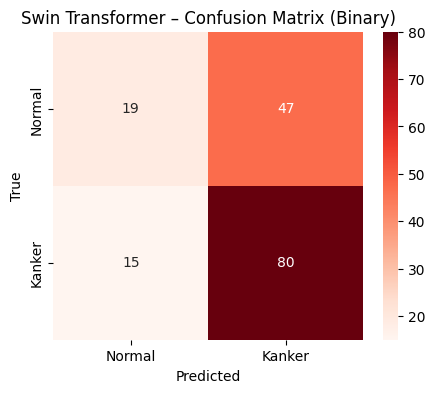

In [ ]:
metrics_bin_swin, (labels_bin_swin, probs_bin_swin) = evaluate_model_binary(
    swin_model, lung_loader, device
)
preds_bin_swin = (probs_bin_swin >= 0.5).astype(int)

plot_confusion_matrix_binary(labels_bin_swin, preds_bin_swin,
                             title="Swin Transformer – Confusion Matrix (Binary)")


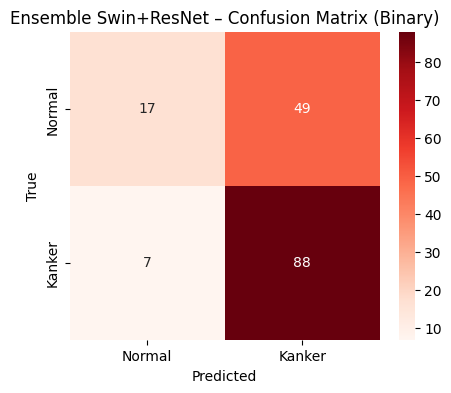

In [ ]:
metrics_bin_ens, (labels_bin_ens, probs_bin_ens) = evaluate_ensemble_binary(
    [swin_model, resnet_model], lung_loader, device
)
preds_bin_ens = (probs_bin_ens >= 0.5).astype(int)

plot_confusion_matrix_binary(labels_bin_ens, preds_bin_ens,
                             title="Ensemble Swin+ResNet – Confusion Matrix (Binary)")
